# TCAD-to-AI Tutorial: Silicon MOSFET Surrogate Modeling and Multi-Objective Optimization

This notebook walks through a complete **TCAD-to-AI workflow** using Silicon MOSFET simulation data. The tutorial starts from Sentaurus Workbench metadata and `.plt` Id-Vg files, converts them into machine-learning-ready datasets, applies unsupervised learning to discover curve patterns, extracts device metrics, trains surrogate models, and finally uses the surrogate model for multi-objective design-space exploration.

The teaching philosophy is:

```text
Physics-based TCAD simulation
        -> structured data extraction
        -> curve-level pattern discovery
        -> compact metric extraction
        -> surrogate modeling
        -> fast design-space screening
        -> TCAD validation of selected designs
```

The surrogate model should be viewed as a **TCAD accelerator and design-intelligence tool**, not as a replacement for TCAD or semiconductor physics. Any AI-generated optimal design should still be checked by physical reasoning and validated by follow-up TCAD simulation.

## Learning Goals

By the end of this notebook, students should be able to:

1. Explain how Sentaurus Workbench DOE information is stored and extracted from `gtree.dat`.
2. Extract Id-Vg curves from TCAD `.plt` files and convert them into a consistent `Vg`/`Id` format.
3. Interpolate raw curves onto a common gate-voltage grid and visually validate the sampling.
4. Construct a log-current feature matrix suitable for unsupervised learning.
5. Use PCA/ICA dimensionality-reduction concepts to understand high-dimensional Id-Vg curve data.
6. Apply KMeans clustering to identify groups of similar electrical behavior.
7. Review clustering quality using the silhouette score and Davies-Bouldin score.
8. Extract compact device metrics: `Ion`, `Ioff`, and `SS`.
9. Train Random Forest and neural-network surrogate models to predict device metrics from design parameters.
10. Interpret Random Forest feature importance for TCAD design variables.
11. Use surrogate predictions to identify Pareto-optimal design candidates.
12. Understand why surrogate-predicted Pareto designs require TCAD validation.

## 0. Design Parameters and Simulation Space

The dataset varies geometry and doping parameters for Silicon MOSFET TCAD simulations. These variables define the **input design space** for the surrogate model. Each row in the Workbench DOE corresponds to one simulated device configuration.

| Type | Parameter | Unit | Range |
|---|---|---:|---:|
| Geometry | Gate length | nm | 10-500 |
| Geometry | Channel length | nm | 100-500 |
| Geometry | Oxide thickness | nm | 8-32 |
| Gaussian doping | Peak value | cm$^{-3}$ | $1\times10^{20}$-$6\times10^{20}$ |
| Gaussian doping | Substrate doping | cm$^{-3}$ | $1\times10^{18}$-$1\times10^{19}$ |
| MOS type | MOS type | - | n, p |
| Bias | Gate voltage (nMOS) | V | -1.0 to 1.5 |
| Bias | Drain voltage (nMOS) | V | 1.0 in this dataset |
| Bias | Gate voltage (pMOS) | V | -1.5 to 1.0 |

### Teaching interpretation

The design variables play different roles:

- **Geometry variables** such as gate length, channel length, and oxide thickness influence electrostatic control, short-channel behavior, drive current, and subthreshold characteristics.
- **Doping variables** influence threshold behavior, leakage, depletion width, and current transport.
- **MOS type** is categorical and should be handled differently from numerical variables in machine learning.
- **Bias conditions** define the electrical operating point under which metrics such as `Ion` and `Ioff` are extracted.

The surrogate model uses geometry, doping, MOS type, and drain bias as inputs. The main metric targets in this teaching version are `Ion`, `Ioff`, and `SS`. `Vth` is discussed conceptually but not used as a training target here because the chosen threshold-current definition may not be valid for every curve.

### Important modeling note

A surrogate model is usually reliable for **interpolation** inside the design space covered by TCAD. It is much less reliable for **extrapolation** outside the simulated ranges. Therefore, later MOO candidate generation is constrained to the observed training design space.

In [ ]:
# ============================================================
# 0. Environment setup
# ============================================================

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")

import glob
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 4)

## 1. Project Folder and Metadata

Expected folder structure:

```text
project_folder/
|-- data/
|   |-- raw_plt/
|   |   |-- gtree.dat
|   |   |-- IdVgsSat_n<node>_des.plt
|-- outputs/
|-- tcad_silicon_surrogate_tutorial.ipynb
```

The tutorial combines two types of information:

| Source | Information provided | Role in the workflow |
|---|---|---|
| `gtree.dat` | Workbench DOE variables and node identifiers | Defines which device was simulated and where its results are stored. |
| `.plt` files | Electrical Id-Vg simulation curves | Provides the response data used for clustering and metric extraction. |

The notebook builds a metadata table with these teaching columns:

```text
sample_id, node, mos_type, gate_length_nm, channel_length_nm,
oxide_thickness_nm, peak_doping_cm3, substrate_doping_cm3,
vds_v, plt_file
```

This metadata table is the bridge between **TCAD simulation management** and **machine-learning dataset construction**. Without this mapping, the Id-Vg curves would not be connected to the design parameters that generated them.

In [ ]:
# ============================================================
# 1. Paths, metadata, and source implementation linkage
# ============================================================

PROJECT_DIR = Path(".")
DATA_DIR = PROJECT_DIR / "data"
RAW_PLT_DIR = DATA_DIR / "raw_plt"
OUTPUT_DIR = PROJECT_DIR / "outputs"
METADATA_FILE = DATA_DIR / "metadata.csv"

SUPPORT_DIR = PROJECT_DIR / "teaching_support"

OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

if SUPPORT_DIR.exists():
    support_dir_str = str(SUPPORT_DIR.resolve())
    if support_dir_str not in sys.path:
        sys.path.append(support_dir_str)

try:
    import tcad_project_helpers as tcad_helpers
    print("Loaded teaching helper routines from:", SUPPORT_DIR / "tcad_project_helpers.py")
except Exception as exc:
    tcad_helpers = None
    print("Teaching helper routines were not loaded.")
    print(type(exc).__name__ + ":", exc)


def load_metadata(metadata_file):
    metadata = pd.read_csv(metadata_file)
    return metadata


expected_columns = [
    "sample_id",
    "mos_type",
    "gate_length_nm",
    "channel_length_nm",
    "oxide_thickness_nm",
    "peak_doping_cm3",
    "substrate_doping_cm3",
    "vds_v",
    "num_nodes",
    "num_edges",
    "plt_file",
]

print("Expected metadata columns:")
print(expected_columns)

# metadata = load_metadata(METADATA_FILE)
# display(metadata.head())

## 1.1 Workflow Map

The notebook follows this processing flow:

```text
gtree.dat + IdVgsSat_n<node>_des.plt
    -> Workbench metadata table
    -> MOS-type filtering
    -> Id-Vg curve extraction
    -> common Vg-grid interpolation
    -> raw-versus-sampled curve validation
    -> curve dataset construction
    -> log-current feature matrix
    -> PCA/ICA dimensionality-reduction review
    -> KMeans clustering
    -> silhouette and Davies-Bouldin score review
    -> metric extraction: Ion, Ioff, SS
    -> surrogate model training
    -> Random Forest feature-importance interpretation
    -> Pareto optimization for Ion and Ioff
```

The helper routines used in the workflow are summarized below.

| Routine | Role |
|---|---|
| `read_workbench_gtree()` | Reads Workbench metadata and returns node/value tables. |
| `read_tcad_plt()` | Reads a TCAD `.plt` file and returns `Vg` and `Id`. |
| `batch_extract_curves()` | Builds aligned curve datasets from many `.plt` files. |
| `prepare_curve_features()` | Converts current curves into log-current vectors. |
| `run_source_clustering()` | Reviews PCA/ICA dimensions, applies PCA, and clusters curves using KMeans. |
| `extract_metrics_for_dataset()` | Extracts `Ion`, `Ioff`, and `SS` for each device. |
| `build_random_forest_surrogate()` | Trains a Random Forest surrogate for metric prediction. |
| `extract_random_forest_feature_importance()` | Lists the relative importance of input variables learned by the Random Forest. |
| `find_pareto_front()` | Finds non-dominated candidates for the MOO problem. |

### Key teaching message

This workflow demonstrates how TCAD results can be transformed from individual simulation outputs into a reusable AI-assisted design framework. Each stage has a specific purpose: extraction ensures data access, interpolation ensures consistent features, clustering reveals patterns, metric extraction gives compact labels, surrogate modeling gives fast prediction, and MOO supports design trade-off exploration.

## 1.2 Reading Workbench `gtree.dat` Metadata

Sentaurus Workbench stores simulation parameters and node identifiers in `gtree.dat`. The notebook converts this file into two pandas DataFrames:

| DataFrame | Meaning |
|---|---|
| `TN` | Node identifiers for each simulation branch. These nodes link the DOE cases to the corresponding Workbench output files. |
| `TV` | Variable values for each simulation branch. These include geometry, doping, MOS type, and bias parameters. |

These tables are combined with the available `.plt` filenames to create the metadata used throughout the notebook.

### What `read_gtree()` does conceptually

`read_gtree()` is the interface between the Workbench DOE and the Python tutorial. It does **not** extract electrical device curves. Instead, it extracts:

```text
Workbench DOE table
        -> node identifiers
        -> design parameter values
        -> mapping between each DOE case and its output files
```

This distinction is important:

| Data source | Extracted information | Later use |
|---|---|---|
| `gtree.dat` / Workbench DOE | Node numbers and design parameters | Input features and file mapping |
| `.plt` files | Id-Vg electrical response | Curve clustering and metric extraction |

In other words, `gtree.dat` tells us **what was simulated**, while the `.plt` files tell us **what electrical response was obtained**.

### Teaching point

Students should recognize that machine-learning datasets for TCAD are usually assembled from multiple sources: simulation setup metadata, output files, and post-processed device metrics. The metadata extraction step is therefore essential for maintaining traceability between design parameters and simulation results.

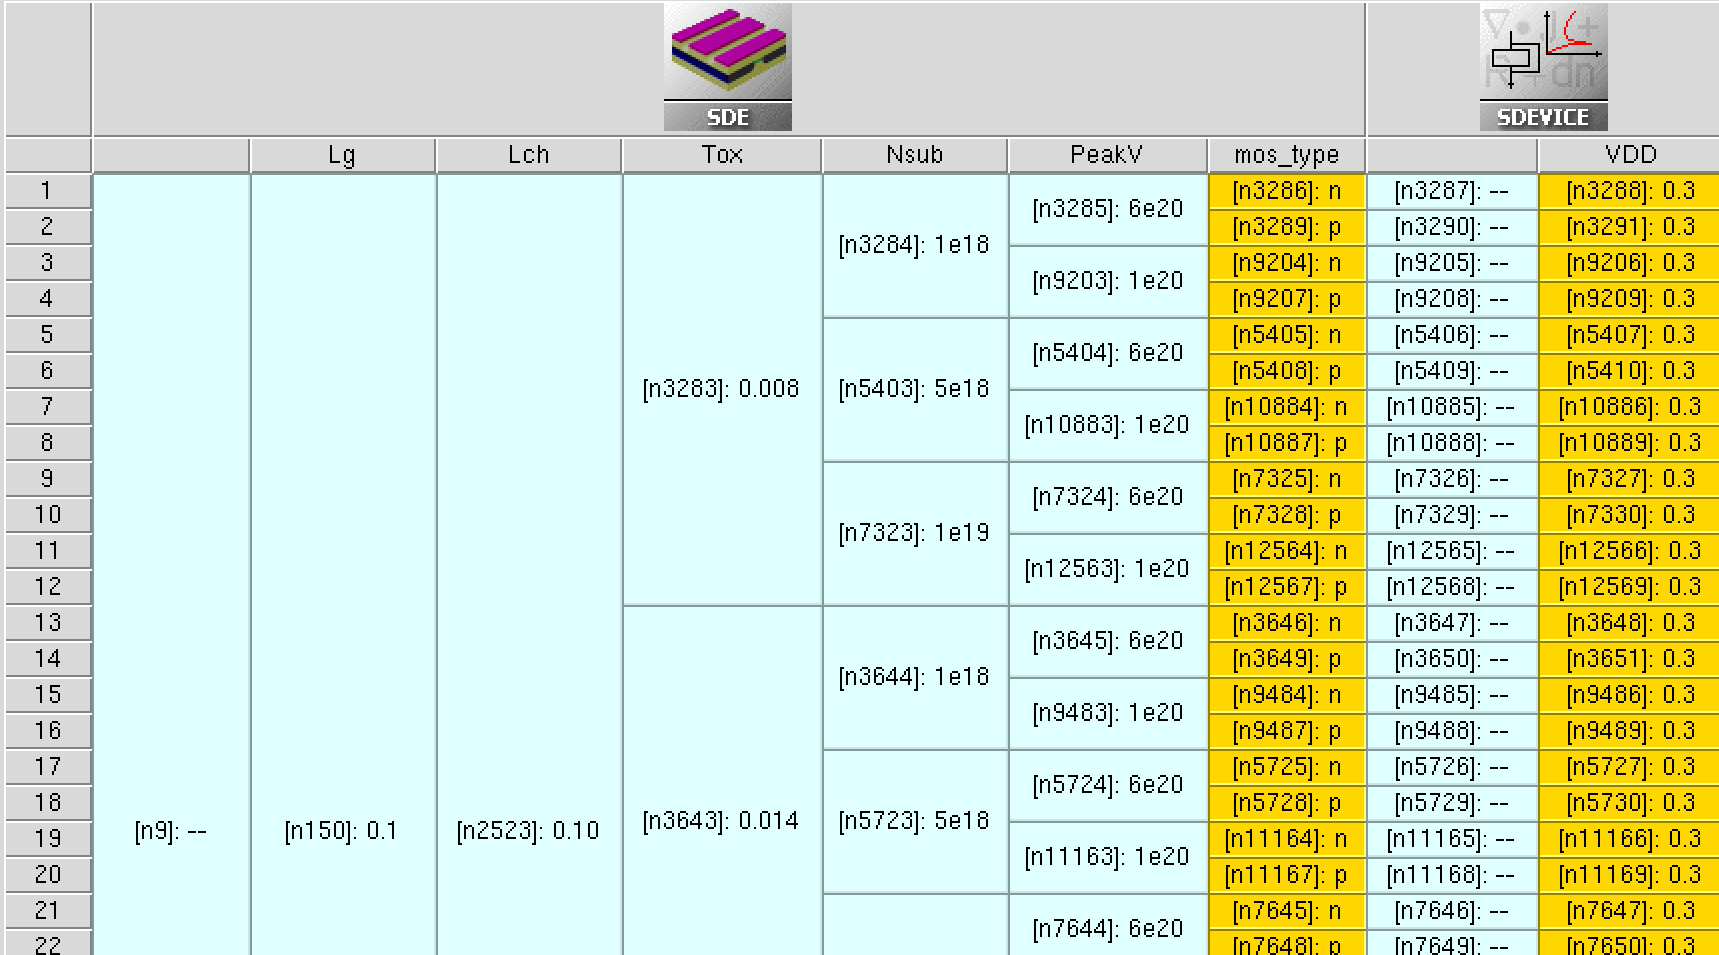

**Figure: Sentaurus Workbench DOE table used by `read_gtree()`.** The Workbench DOE table stores both the parameter values and the node identifiers generated during the simulation sweep. The parameter columns, such as `Lg`, `Lch`, `Tox`, `Nsub`, `PeakV`, `mos_type`, and `VDD`, become the input features for the later machine-learning workflow. The node identifiers are used to match each DOE case to its corresponding `.plt` result file. Therefore, `read_gtree()` provides the bridge between the Workbench DOE setup and the Python-based TCAD-to-AI dataset construction.

In [ ]:
# ============================================================
# 1.2 Workbench gtree.dat metadata extraction
# ============================================================

TARGET_MOS_TYPE = "n"
NUM_CURVE_POINTS = 100


def read_workbench_gtree(gtree_file):
    """
    Read Sentaurus Workbench gtree.dat metadata using the project implementation.

    Returns:
        TN: DataFrame containing node identifiers.
        TV: DataFrame containing variable values.
    """
    if tcad_helpers is None:
        raise RuntimeError("Teaching helper routines are not loaded. Check SUPPORT_DIR in Section 1.")

    workbench_n, workbench_v = tcad_helpers.read_gtree(str(gtree_file))

    tn = pd.DataFrame(workbench_n[1:], columns=workbench_n[0])
    tv = pd.DataFrame(workbench_v[1:], columns=workbench_v[0])

    return tn, tv


def filter_workbench_by_mos_type(tn, tv, mos_type="n", mos_type_column="nMOS_mos_type"):
    """
    Filter Workbench node and value tables by MOS type, matching main.py.
    """
    if mos_type_column not in tv.columns:
        raise KeyError(f"Column {mos_type_column!r} was not found in the Workbench value table.")

    mask = tv[mos_type_column] == mos_type
    tn_filtered = tn[mask].reset_index(drop=True)
    tv_filtered = tv[mask].reset_index(drop=True)

    return tn_filtered, tv_filtered


def get_available_plt_files(raw_plt_dir):
    """
    Return a mapping from Workbench node ID to PLT filename for files named
    IdVgsSat_n<node>_des.plt.
    """
    raw_plt_dir = Path(raw_plt_dir)
    node_to_file = {}

    for path in raw_plt_dir.glob("IdVgsSat_n*_des.plt"):
        match = re.search(r"IdVgsSat_n(\d+)_des\.plt$", path.name)
        if match:
            node_to_file[match.group(1)] = path.name

    return node_to_file


def build_metadata_from_workbench(tn, tv, raw_plt_dir, mos_type="n"):
    """
    Build the teaching metadata table from gtree.dat and the actual PLT files present.

    The original Workbench table contains 2400 simulation cases in this dataset, but only
    the cases with matching IdVgsSat_n<node>_des.plt files can be extracted here.
    """
    node_to_file = get_available_plt_files(raw_plt_dir)

    metadata = tv.copy()
    metadata["node"] = tn["SingleDevice_VDD"].astype(str)
    metadata["sample_id"] = metadata["node"]
    metadata["plt_file"] = metadata["node"].map(node_to_file)
    metadata["mos_type"] = metadata["nMOS_mos_type"].str.lower()

    # Convert Workbench dimensions from micrometers to nanometers for teaching tables.
    metadata["gate_length_nm"] = pd.to_numeric(metadata["nMOS_Lg"], errors="coerce") * 1000.0
    metadata["channel_length_nm"] = pd.to_numeric(metadata["nMOS_Lch"], errors="coerce") * 1000.0
    metadata["oxide_thickness_nm"] = pd.to_numeric(metadata["nMOS_Tox"], errors="coerce") * 1000.0
    metadata["peak_doping_cm3"] = pd.to_numeric(metadata["nMOS_PeakV"], errors="coerce")
    metadata["substrate_doping_cm3"] = pd.to_numeric(metadata["nMOS_Nsub"], errors="coerce")
    metadata["vds_v"] = pd.to_numeric(metadata["SingleDevice_VDD"], errors="coerce")
    metadata["num_nodes"] = np.nan
    metadata["num_edges"] = np.nan

    metadata = metadata[(metadata["mos_type"] == mos_type.lower()) & metadata["plt_file"].notna()].copy()
    metadata = metadata.reset_index(drop=True)

    ordered_cols = [
        "sample_id", "node", "mos_type", "gate_length_nm", "channel_length_nm",
        "oxide_thickness_nm", "peak_doping_cm3", "substrate_doping_cm3", "vds_v",
        "num_nodes", "num_edges", "plt_file",
    ]
    remaining_cols = [col for col in metadata.columns if col not in ordered_cols]
    return metadata[ordered_cols + remaining_cols]


GTREE_FILE = RAW_PLT_DIR / "gtree.dat"

if GTREE_FILE.exists():
    TN, TV = read_workbench_gtree(GTREE_FILE)
    metadata = build_metadata_from_workbench(TN, TV, RAW_PLT_DIR, mos_type=TARGET_MOS_TYPE)
    metadata.to_csv(OUTPUT_DIR / f"metadata_from_gtree_{TARGET_MOS_TYPE}.csv", index=False)

    print(f"Workbench rows: {len(TV)}")
    print(f"Available {TARGET_MOS_TYPE}MOS PLT-backed rows: {len(metadata)}")
    display(metadata.head())
elif METADATA_FILE.exists():
    metadata = load_metadata(METADATA_FILE)
    print(f"Loaded metadata.csv rows: {len(metadata)}")
    display(metadata.head())
else:
    metadata = pd.DataFrame(columns=expected_columns)
    print("No gtree.dat or metadata.csv found. Add data before running extraction cells.")

## 2. Extract Id-Vg Curves from `.plt` Files

Each `.plt` file contains one simulated Id-Vg sweep. The notebook reads each file and normalizes the output to two columns:

```text
Vg: gate voltage
Id: drain current
```

The expected TCAD fields are:

```text
gate_OuterVoltage
drain_TotalCurrent
```

Keeping a simple `Vg`/`Id` interface makes the rest of the workflow independent of the original TCAD file format.

### Why curve extraction matters

TCAD output files are designed for simulation tools, not directly for machine learning. Before applying AI models, we need to convert the output into a clean tabular structure. The extracted Id-Vg curve is the central data object used in the next steps:

```text
raw .plt file
    -> Vg and Id arrays
    -> aligned curve vector
    -> log-current feature vector
    -> clustering / metric extraction / surrogate modeling
```

### Current sign and scale convention

The notebook uses `log10(abs(Id))` in later curve-based learning. This avoids issues with current sign conventions for nMOS and pMOS and allows the algorithm to compare current magnitude over many orders of magnitude. However, students should remember that the sign of current can still carry physical meaning in device simulation; the absolute-value convention is a practical preprocessing choice for this tutorial.

In [ ]:
# ============================================================
# 2. PLT extraction using the project parser when available
# ============================================================

PROJECT_VG_COL = "gate_OuterVoltage"
PROJECT_ID_COL = "drain_TotalCurrent"


def read_tcad_plt(file_path):
    """
    Read a TCAD Id-Vg file and return a normalized DataFrame with columns ["Vg", "Id"].

    Preferred path:
        Use tcad_project_helpers.read_plt() from the teaching support module.

    Fallback path:
        Use a simple two-column text parser for teaching examples or simplified fixtures.
    """
    file_path = Path(file_path)

    if tcad_helpers is not None:
        csv_path = file_path.with_suffix(".csv")

        if csv_path.exists():
            parsed = pd.read_csv(csv_path)
        else:
            data_result = tcad_helpers.read_plt(str(file_path))
            if data_result is None:
                raise FileNotFoundError(f"Could not parse {file_path}")
            parsed = pd.DataFrame(data_result[1:], columns=data_result[0])

        missing = {PROJECT_VG_COL, PROJECT_ID_COL} - set(parsed.columns)
        if missing:
            raise ValueError(f"Parsed TCAD file is missing expected columns: {sorted(missing)}")

        return parsed[[PROJECT_VG_COL, PROJECT_ID_COL]].rename(
            columns={PROJECT_VG_COL: "Vg", PROJECT_ID_COL: "Id"}
        )

    data = []
    with open(file_path, "r", errors="ignore") as f:
        for line in f:
            line = line.strip()

            if (not line) or line.startswith("#") or line.startswith("*"):
                continue

            parts = line.replace(",", " ").split()

            try:
                vg = float(parts[0])
                id_value = float(parts[1])
                data.append([vg, id_value])
            except Exception:
                continue

    return pd.DataFrame(data, columns=["Vg", "Id"])


def plot_single_idvg(df_curve, title="Id-Vg Curve"):
    plt.figure()
    plt.plot(df_curve["Vg"], df_curve["Id"])
    plt.xlabel("Gate voltage, Vg (V)")
    plt.ylabel("Drain current, Id (A)")
    plt.title(title + " - Linear scale")
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.semilogy(df_curve["Vg"], np.maximum(np.abs(df_curve["Id"]), 1e-30))
    plt.xlabel("Gate voltage, Vg (V)")
    plt.ylabel("|Drain current|, |Id| (A)")
    plt.title(title + " - Log scale")
    plt.grid(True)
    plt.show()


# Example after metadata is available:
# first_file = RAW_PLT_DIR / metadata.loc[0, "plt_file"]
# df_curve = read_tcad_plt(first_file)
# display(df_curve.head())
# plot_single_idvg(df_curve, title=f"Sample {metadata.loc[0, 'sample_id']}")

## 3. Batch Processing and Curve Alignment

Machine learning models require fixed-length input vectors. Since raw TCAD curves may not all share the same voltage samples, each Id-Vg curve is interpolated onto a common gate-voltage grid.

For this dataset:

- nMOS grid: -1.0 V to 1.5 V
- pMOS grid: 1.0 V to -1.5 V
- number of interpolation points: 100

The resulting curve matrix has one row per device and one current feature per voltage-grid point.

### Why interpolation is needed

Raw TCAD sweeps may contain different voltage points, sweep directions, or numerical step sizes. Most machine-learning algorithms expect a fixed number of features for every sample. Interpolation converts each curve into the same representation:

```text
Device 1: Id(Vg_1), Id(Vg_2), ..., Id(Vg_100)
Device 2: Id(Vg_1), Id(Vg_2), ..., Id(Vg_100)
...
```

This makes the curve dataset suitable for PCA, ICA, KMeans clustering, and other machine-learning methods.

### Raw-versus-sampled validation

After interpolation, it is good practice to compare a raw curve with the sampled curve. This check confirms that the common Vg grid preserves the original TCAD behavior. Linear-scale plots highlight ON-state agreement, while log-scale plots highlight OFF-state and subthreshold agreement.

If the sampled curve deviates significantly from the raw curve, possible causes include an inappropriate voltage grid, insufficient sampling resolution, current sign issues, or interpolation outside the raw sweep range.

In [ ]:
# ============================================================
# 3. Curve interpolation and batch extraction
# ============================================================

def get_vg_grid(mos_type, num_points=251):
    mos_type = mos_type.lower()

    if mos_type == "n":
        return np.linspace(-1.0, 1.5, num_points)
    elif mos_type == "p":
        return np.linspace(-1.5, 1.0, num_points)
    else:
        raise ValueError("mos_type must be 'n' or 'p'")


def interpolate_curve(df_curve, vg_grid):
    df_curve = df_curve.copy()
    df_curve["Vg"] = pd.to_numeric(df_curve["Vg"], errors="coerce")
    df_curve["Id"] = pd.to_numeric(df_curve["Id"], errors="coerce")
    df_curve = df_curve.dropna(subset=["Vg", "Id"]).sort_values("Vg")
    df_curve = df_curve.drop_duplicates(subset=["Vg"], keep="first")

    if df_curve.empty:
        raise ValueError("Curve has no numeric Vg/Id samples after cleaning.")

    id_interp = np.interp(vg_grid, df_curve["Vg"].values, df_curve["Id"].values)
    return id_interp


def batch_extract_curves(metadata, raw_plt_dir, num_points=251):
    curve_records = []
    curve_matrix = []
    vg_grid_records = []
    kept_metadata = []
    failure_records = []

    for _, row in metadata.iterrows():
        file_path = Path(raw_plt_dir) / row["plt_file"]
        mos_type = row["mos_type"]

        try:
            vg_grid = get_vg_grid(mos_type, num_points=num_points)
            df_curve = read_tcad_plt(file_path)
            id_interp = interpolate_curve(df_curve, vg_grid)
        except Exception as exc:
            failure_records.append({
                "sample_id": row.get("sample_id", None),
                "plt_file": row.get("plt_file", None),
                "error": f"{type(exc).__name__}: {exc}",
            })
            continue

        curve_matrix.append(id_interp)
        vg_grid_records.append(vg_grid)
        kept_metadata.append(row.to_dict())

        for vg, id_value in zip(vg_grid, id_interp):
            curve_records.append({
                "sample_id": row["sample_id"],
                "mos_type": mos_type,
                "Vg": vg,
                "Id": id_value,
            })

    curves_long = pd.DataFrame(curve_records)
    curves_matrix = np.array(curve_matrix)
    vg_grid_records = np.array(vg_grid_records)
    curve_metadata = pd.DataFrame(kept_metadata)
    extraction_failures = pd.DataFrame(failure_records)

    if curves_matrix.size == 0:
        raise RuntimeError("No curves were extracted. Check metadata, PLT filenames, and parser assumptions.")

    return curves_long, curves_matrix, vg_grid_records, curve_metadata, extraction_failures


if not metadata.empty:
    curves_long, curves_matrix, vg_grids, curve_metadata, extraction_failures = batch_extract_curves(
        metadata,
        RAW_PLT_DIR,
        num_points=NUM_CURVE_POINTS,
    )

    curves_long.to_csv(OUTPUT_DIR / f"processed_curves_long_{TARGET_MOS_TYPE}.csv", index=False)
    curve_matrix_df = pd.DataFrame(curves_matrix, columns=[f"I{i}" for i in range(curves_matrix.shape[1])])
    curve_matrix_df.insert(0, "sample_id", curve_metadata["sample_id"].values)
    curve_matrix_df.to_csv(OUTPUT_DIR / f"processed_curve_matrix_{TARGET_MOS_TYPE}.csv", index=False)
    curve_metadata.to_csv(OUTPUT_DIR / f"curve_metadata_{TARGET_MOS_TYPE}.csv", index=False)

    print("Extracted curve matrix shape:", curves_matrix.shape)
    print("Long curve table shape:", curves_long.shape)
    print("Extraction failures:", len(extraction_failures))
    display(curve_metadata.head())
else:
    curves_long = pd.DataFrame()
    curves_matrix = np.empty((0, 0))
    vg_grids = np.empty((0, 0))
    curve_metadata = pd.DataFrame()
    extraction_failures = pd.DataFrame()
    print("Skipping curve extraction because metadata is empty.")

In [ ]:
# ============================================================
# 3.1 Optional bridge to the original Ion/SS extraction routine
# ============================================================


def extract_with_project_subroutine(node, folder_path, mos_type="n", num_points=100):
    """
    Use the teaching support extraction routine for one Workbench node.

    Returns a teaching-friendly dictionary containing the interpolated current vector,
    extracted metrics, and original Vg/Id samples.
    """
    if tcad_helpers is None:
        raise RuntimeError("Teaching helper routines are not loaded. Check SUPPORT_DIR in Section 1.")

    mos_type = mos_type.lower()
    if mos_type == "n":
        voff, von, order, v0, v1 = -0.5, 0.5, 1e3, -1.0, 1.5
    elif mos_type == "p":
        voff, von, order, v0, v1 = 0.0, -1.0, 1e3, 1.0, -1.5
    else:
        raise ValueError("mos_type must be 'n' or 'p'")

    vg_grid = np.linspace(v0, v1, num_points)
    result = tcad_helpers.extract_data(node, vg_grid, voff, von, order, str(folder_path))

    if result is None:
        return None

    current_interp, ss, ioff, ion, vg_original, id_original = result
    return {
        "node": node,
        "mos_type": mos_type,
        "Vg_grid": vg_grid,
        "Id_interp": current_interp,
        "Ioff": ioff,
        "Ion": ion,
        "SS_mV_dec": ss,
        "Vg_original": vg_original,
        "Id_original": id_original,
    }


# Example for a Sentaurus Workbench folder:
# record = extract_with_project_subroutine(node=42, folder_path=Path("path/to/VDD5"), mos_type="n")
# record["Ion"], record["Ioff"], record["SS_mV_dec"]

## 4. Visualize the Id-Vg Dataset

Before applying machine learning, inspect the distribution of curves in log scale. This is a useful sanity check because MOSFET current can vary across many orders of magnitude.

The visualization uses:

```text
x-axis: gate voltage Vg
y-axis: log10(|Id|)
```

### What students should look for

1. **Threshold shift:** Are some curves shifted left or right along the Vg axis?
2. **Leakage variation:** Which curves have high current in the nominal OFF region?
3. **Drive-current variation:** Which curves have strong ON-state current?
4. **Subthreshold behavior:** Which curves show a steeper or weaker transition?
5. **Possible behavior groups:** Can we visually identify families of similar curves?

### Why visualization comes before clustering

Clustering algorithms will always return labels, but those labels are only meaningful if the data contain real structure. Visual inspection helps students build physical intuition before applying unsupervised learning. It also helps catch problems such as missing files, noisy curves, wrong current signs, or failed simulations.

In [ ]:
# ============================================================
# 4. Curve visualization
# ============================================================

def plot_curve_collection(curves_long, mos_type=None, max_curves=100):
    df = curves_long.copy()

    if mos_type is not None:
        df = df[df["mos_type"].str.lower() == mos_type.lower()]

    sample_ids = df["sample_id"].drop_duplicates().values[:max_curves]

    plt.figure()

    for sid in sample_ids:
        temp = df[df["sample_id"] == sid]
        plt.plot(temp["Vg"], np.log10(np.abs(temp["Id"]) + 1e-30), alpha=0.3)

    plt.xlabel("Gate voltage, Vg (V)")
    plt.ylabel("log10(|Id|)")
    plt.title("Collection of TCAD Id-Vg Curves")
    plt.grid(True)
    plt.show()


# plot_curve_collection(curves_long, mos_type="n")
# plot_curve_collection(curves_long, mos_type="p")

In [ ]:
# Run a compact visual check of the extracted curves.
if not curves_long.empty:
    plot_curve_collection(curves_long, mos_type=TARGET_MOS_TYPE, max_curves=75)

## 5. Unsupervised Learning: Clustering Id-Vg Patterns

Clustering helps identify groups of devices with similar Id-Vg behavior before supervised modeling. Unlike supervised learning, clustering does not use known labels such as `Ion`, `Ioff`, or `SS`. Instead, it groups curves based on the similarity of their full Id-Vg shapes.

The clustering workflow is:

```text
aligned Id-Vg curves
    -> log10(|Id|) feature matrix
    -> PCA/ICA dimensionality-reduction review
    -> KMeans clustering
    -> silhouette and Davies-Bouldin score review
    -> cluster interpretation using Id-Vg curves and metrics
```

### Why use `log10(|Id|)` as the curve feature?

MOSFET current often spans many orders of magnitude from the OFF-state to the ON-state. If raw current is used directly, clustering may be dominated by the ON-current region. Using `log10(|Id|)` allows the clustering process to consider leakage, subthreshold transition, and ON-state behavior together.

### PCA dimensionality reduction

Principal Component Analysis (PCA) transforms the original high-dimensional curve vectors into a smaller set of orthogonal components:

```text
100-point Id-Vg curve -> PC1, PC2, PC3, ...
```

PCA finds directions that capture the largest variance in the data. In this tutorial, PCA is used for two purposes:

1. **Visualization:** PC1 and PC2 provide a low-dimensional view of the curve dataset.
2. **Clustering input:** KMeans can be applied to the reduced PCA features instead of the original 100-dimensional curve vector.

Physically, the first few principal components may reflect dominant curve variations such as threshold shift, leakage level, or ON-current strength. However, PCA components are mathematical combinations of voltage-point currents, so they should be interpreted carefully rather than treated as direct physical parameters.

### ICA dimensionality review

Independent Component Analysis (ICA) is also reviewed in the scoring stage. While PCA seeks uncorrelated directions that maximize variance, ICA seeks statistically independent components. Conceptually:

| Method | Main idea | Typical use in this tutorial |
|---|---|---|
| PCA | Captures directions of maximum variance | Stable dimensionality reduction and visualization |
| ICA | Attempts to separate independent latent sources | Alternative dimensionality-reduction comparison |

The current final clustering choice follows the source-style PCA/KMeans path, but reviewing ICA scores helps students see that dimensionality reduction is not unique and that different transformations can influence clustering quality.

### KMeans clustering

KMeans partitions the reduced feature space into `k` clusters. It tries to minimize the distance between each point and its assigned cluster center. In this context:

```text
one point = one device Id-Vg curve represented in PCA space
one cluster = a group of devices with similar curve behavior
```

KMeans requires choosing the number of clusters. Too few clusters may merge physically different behaviors; too many clusters may split small variations into artificial groups.

### Silhouette score

The silhouette score measures how well each point fits within its assigned cluster compared with neighboring clusters.

```text
Higher silhouette score -> better separation and compactness
Approximate range: -1 to 1
```

A high score suggests that curves within the same cluster are similar and curves in different clusters are well separated.

### Davies-Bouldin score

The Davies-Bouldin score evaluates the ratio of within-cluster scatter to between-cluster separation.

```text
Lower Davies-Bouldin score -> better clustering
```

A low value suggests compact clusters that are far apart from each other.

### How to use both scores

The two metrics should be interpreted together:

| Metric | Better direction | What it emphasizes |
|---|---:|---|
| Silhouette score | Higher is better | Separation and assignment quality |
| Davies-Bouldin score | Lower is better | Compactness versus separation |

The best numerical score is not always the best engineering choice. Students should also inspect the Id-Vg curves within each cluster and ask whether the clusters correspond to meaningful device behaviors.

The cluster labels are later attached to the curve and metric datasets for physical interpretation.

In [ ]:
# ============================================================
# 5. Clustering utilities
# ============================================================

from sklearn.metrics import davies_bouldin_score

SOURCE_FEATURE_MIN = 2
SOURCE_FEATURE_MAX = 4
SOURCE_CLUSTER_MIN = 20
SOURCE_CLUSTER_MAX = 22


def prepare_curve_features(curves_matrix):
    """
    Match main.py exactly: use log10(abs(I)) with no scaler.

    The source script has a commented-out normalization line, but the executed path
    uses the unscaled log-current matrix.
    """
    X_log = pd.DataFrame(np.log10(np.abs(curves_matrix)))

    if not np.isfinite(X_log.to_numpy()).all():
        raise ValueError("Source-style clustering features contain non-finite values.")

    return X_log


def source_score_grid_to_dataframe(pca_sil, pca_db, ica_sil, ica_db, feature_min, cluster_min):
    records = []
    grids = [
        ("PCA", pca_sil, pca_db),
        ("ICA", ica_sil, ica_db),
    ]

    for method, sil_grid, db_grid in grids:
        for feature_offset, sil_row in enumerate(sil_grid):
            for cluster_offset, silhouette in enumerate(sil_row):
                records.append({
                    "method": method,
                    "n_features": feature_min + feature_offset,
                    "n_clusters": cluster_min + cluster_offset,
                    "silhouette_score": silhouette,
                    "davies_bouldin_score": db_grid[feature_offset][cluster_offset],
                })

    return pd.DataFrame(records)


def run_source_clustering(X_log):
    """
    Follow the same PCA/KMeans scoring method used in the helper module:

    1. Search PCA and ICA reduced dimensions with run_clustering_and_score().
    2. Rank PCA silhouette scores with clustering_score_analysis().
    3. Select index 1, matching main.py's final clustering choice.
    4. Fit PCA and KMeans with the selected dimensions and cluster count.
    """
    if tcad_helpers is None:
        raise RuntimeError("Teaching helper routines are not loaded. Check SUPPORT_DIR in Section 1.")

    pca_sil, pca_db, ica_sil, ica_db = tcad_helpers.run_clustering_and_score(
        X_log,
        SOURCE_FEATURE_MIN,
        SOURCE_FEATURE_MAX,
        SOURCE_CLUSTER_MIN,
        SOURCE_CLUSTER_MAX,
    )

    top_pca_db = tcad_helpers.clustering_score_analysis(
        pca_db,
        SOURCE_FEATURE_MIN,
        SOURCE_CLUSTER_MIN,
        0,
    )
    top_pca_sil = tcad_helpers.clustering_score_analysis(
        pca_sil,
        SOURCE_FEATURE_MIN,
        SOURCE_CLUSTER_MIN,
        1,
    )

    selected_feature_count, selected_cluster_count, selected_silhouette = top_pca_sil[1]

    pca_model = PCA(n_components=selected_feature_count)
    X_pca = pca_model.fit_transform(X_log)
    kmeans_model = KMeans(
        n_clusters=selected_cluster_count,
        n_init="auto",
        random_state=0,
    ).fit(X_pca)

    score_table = source_score_grid_to_dataframe(
        pca_sil,
        pca_db,
        ica_sil,
        ica_db,
        SOURCE_FEATURE_MIN,
        SOURCE_CLUSTER_MIN,
    )

    selection = {
        "n_features": selected_feature_count,
        "n_clusters": selected_cluster_count,
        "silhouette_score": selected_silhouette,
        "top_pca_silhouette": top_pca_sil,
        "top_pca_davies_bouldin": top_pca_db,
    }

    return kmeans_model.labels_, kmeans_model, pca_model, X_pca, score_table, selection


def plot_pca_clusters(X_pca, labels=None):
    plt.figure()

    if labels is None:
        plt.scatter(X_pca[:, 0], X_pca[:, 1])
    else:
        plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Source-Style PCA Projection of Id-Vg Curves")
    plt.grid(True)
    plt.show()

In [ ]:
# Execute source-consistent PCA/KMeans clustering.
if curves_matrix.size > 0:
    X_log = prepare_curve_features(curves_matrix)
    labels, kmeans_model, pca_model, X_pca, k_results, clustering_selection = run_source_clustering(X_log)
    plot_pca_clusters(X_pca, labels)

    clustered_curve_metadata = curve_metadata.copy()
    clustered_curve_metadata["cluster"] = labels

    curves_long_clustered = curves_long.merge(
        clustered_curve_metadata[["sample_id", "cluster"]],
        on="sample_id",
        how="left",
    )

    k_results.to_csv(OUTPUT_DIR / f"kmeans_scores_{TARGET_MOS_TYPE}.csv", index=False)
    pd.DataFrame([{
        "selected_n_features": clustering_selection["n_features"],
        "selected_n_clusters": clustering_selection["n_clusters"],
        "selected_silhouette_score": clustering_selection["silhouette_score"],
        "selection_rule": "top_pca_silhouette[1], matching main.py",
    }]).to_csv(OUTPUT_DIR / f"clustering_selection_{TARGET_MOS_TYPE}.csv", index=False)
    clustered_curve_metadata.to_csv(OUTPUT_DIR / f"clustered_curve_metadata_{TARGET_MOS_TYPE}.csv", index=False)
    curves_long_clustered.to_csv(OUTPUT_DIR / f"processed_curves_long_clustered_{TARGET_MOS_TYPE}.csv", index=False)
    joblib.dump(kmeans_model, OUTPUT_DIR / f"kmeans_curve_clusterer_{TARGET_MOS_TYPE}.pkl")
    joblib.dump(pca_model, OUTPUT_DIR / f"pca_curve_projection_{TARGET_MOS_TYPE}.pkl")

    print("Selected source-style PCA features:", clustering_selection["n_features"])
    print("Selected source-style KMeans clusters:", clustering_selection["n_clusters"])
    print("Selection rule: top_pca_silhouette[1], matching main.py")
    display(k_results)
    display(clustered_curve_metadata[["sample_id", "mos_type", "plt_file", "cluster"]].head())
else:
    print("Skipping clustering because no curve matrix was extracted.")

### 5.1 Interpreting Clustered Id-Vg Curves

After clustering, the notebook saves one Id-Vg plot per cluster and one combined plot. This step is important because clustering results should not be judged only by numerical scores.

For each cluster, students should compare:

- OFF-state current level;
- ON-state current level;
- apparent threshold shift;
- subthreshold slope behavior;
- curve failures or outliers;
- dominant design-variable values within the cluster.

A useful interpretation exercise is to label clusters qualitatively, for example:

```text
Cluster A: high Ion but higher leakage
Cluster B: low leakage but weaker drive current
Cluster C: shifted threshold behavior
Cluster D: abnormal or failed simulation cases
```

These qualitative labels help connect unsupervised machine-learning outputs back to semiconductor device physics.

In [ ]:
# ============================================================
# 5.1 Save one plot per cluster and one combined cluster plot
# ============================================================

CLUSTER_PLOT_DIR = OUTPUT_DIR / "cluster"
CLUSTER_PLOT_DIR.mkdir(exist_ok=True, parents=True)


def save_cluster_curve_plots(curves_long_clustered, output_dir, target_mos_type="n"):
    """
    Save one Id-Vg curve collection plot per cluster and a combined plot.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)

    df = curves_long_clustered.copy()
    df = df[df["cluster"].notna()].copy()
    df["cluster"] = df["cluster"].astype(int)

    clusters = sorted(df["cluster"].unique())
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(clusters), 1)))
    color_map = dict(zip(clusters, colors))

    for cluster in clusters:
        subset = df[df["cluster"] == cluster]

        plt.figure(figsize=(9, 6))
        for sample_id, curve in subset.groupby("sample_id"):
            plt.plot(
                curve["Vg"],
                np.log10(np.abs(curve["Id"]) + 1e-30),
                color=color_map[cluster],
                alpha=0.35,
                linewidth=0.9,
            )

        plt.xlabel("Gate voltage, Vg (V)")
        plt.ylabel("log10(|Id|)")
        plt.title(f"{target_mos_type}MOS Id-Vg Curves - Cluster {cluster}")
        plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
        plt.tight_layout()
        plt.savefig(output_dir / f"cluster_{cluster:02d}.png", dpi=200)
        plt.close()

    plt.figure(figsize=(10, 7))
    for cluster in clusters:
        subset = df[df["cluster"] == cluster]
        first = True
        for sample_id, curve in subset.groupby("sample_id"):
            plt.plot(
                curve["Vg"],
                np.log10(np.abs(curve["Id"]) + 1e-30),
                color=color_map[cluster],
                alpha=0.22,
                linewidth=0.8,
                label=f"Cluster {cluster}" if first else None,
            )
            first = False

    plt.xlabel("Gate voltage, Vg (V)")
    plt.ylabel("log10(|Id|)")
    plt.title(f"{target_mos_type}MOS Id-Vg Curves - All Clusters")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    plt.legend(loc="best", fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig(output_dir / "combined_clusters.png", dpi=200)
    plt.close()

    return clusters


if "curves_long_clustered" in globals() and not curves_long_clustered.empty:
    saved_clusters = save_cluster_curve_plots(
        curves_long_clustered,
        CLUSTER_PLOT_DIR,
        target_mos_type=TARGET_MOS_TYPE,
    )
    print(f"Saved {len(saved_clusters)} cluster plots plus combined plot to {CLUSTER_PLOT_DIR}")
else:
    print("Skipping cluster plot export because clustered curve data is unavailable.")

## 6. Extract Device Metrics: Ion, Ioff, and SS

The notebook extracts compact device metrics from each Id-Vg curve. This step converts a full electrical curve into a small set of physically meaningful performance indicators.

For nMOS:

| Metric | Definition |
|---|---|
| `Ioff` | `Id` interpolated at `Vg = -0.5 V` |
| `Ion` | `Id` interpolated at `Vg = 0.5 V` |
| `SS` | Voltage shift between `Ioff` and `Ioff * 1e3`, converted to mV/dec |

For pMOS:

| Metric | Definition |
|---|---|
| `Ioff` | `Id` interpolated at `Vg = 0 V` |
| `Ion` | `Id` interpolated at `Vg = -1 V` |
| `SS` | Same current-ratio method as nMOS |

### Physical meaning of each metric

| Metric | Physical interpretation | Design preference |
|---|---|---|
| `Ion` | ON-state drive current | Larger is generally better |
| `Ioff` | OFF-state leakage current | Smaller is generally better |
| `SS` | Gate-voltage efficiency in switching the device | Smaller is generally better |

`Ion` reflects the ability of the transistor to deliver current in the ON state. `Ioff` reflects leakage in the OFF state. `SS` reflects how sharply the device turns on; a smaller SS means a smaller gate-voltage change is required for each decade increase in current.

### Why metric definitions must be explicit

Different papers, technologies, and design targets may define `Ion`, `Ioff`, `Vth`, and `SS` differently. For example, `Ion` can be defined at a fixed `Vg`, a fixed overdrive, or a technology-specific supply voltage. `Vth` can be extracted by constant-current, maximum-transconductance, or linear-extrapolation methods.

In this tutorial, simple definitions are used for teaching clarity. Students should understand that changing the extraction rule can change the numerical metric values and therefore affect the surrogate model and Pareto front.

### Why `Vth` is not used as a target here

`Vth` is not used as a training target in this teaching version because the selected threshold-current definition is not available for every curve. This is a realistic data-quality issue in TCAD-AI workflows: not every metric can be robustly extracted from every simulation. Rather than forcing an unreliable label, the notebook focuses on metrics that can be consistently extracted.

In [ ]:
# ============================================================
# 6. Metric extraction
# ============================================================


def get_project_metric_settings(mos_type, num_points=100):
    """
    Return the same metric-extraction settings used in main.py.
    """
    mos_type = mos_type.lower()

    if mos_type == "n":
        return {
            "Voff": -0.5,
            "Von": 0.5,
            "Order": 1e3,
            "V": np.linspace(-1.0, 1.5, num_points),
        }
    elif mos_type == "p":
        return {
            "Voff": 0.0,
            "Von": -1.0,
            "Order": 1e3,
            "V": np.linspace(1.0, -1.5, num_points),
        }
    else:
        raise ValueError("mos_type must be 'n' or 'p'")


def extract_vth_from_curve(vg, id_values, ith=1e-7):
    """
    Notebook-only teaching metric. Vth is not implemented in the helper metric routine.
    """
    id_abs = np.maximum(np.abs(id_values), 1e-30)
    log_id = np.log10(id_abs)

    if not (np.min(id_abs) <= ith <= np.max(id_abs)):
        return np.nan

    sort_idx = np.argsort(log_id)
    return np.interp(np.log10(ith), log_id[sort_idx], np.asarray(vg)[sort_idx])


def extract_metrics_from_project_file(row, raw_plt_dir, num_points=100, ith=1e-7):
    """
    Extract Ion, Ioff, and SS using the teaching helper Ion_SS_extraction() routine.

    Vth is added as a notebook-only teaching metric because the project source does
    not define Vth extraction.
    """
    if tcad_helpers is None:
        raise RuntimeError("Teaching helper routines are not loaded. Check SUPPORT_DIR in Section 1.")

    settings = get_project_metric_settings(row["mos_type"], num_points=num_points)
    file_path = Path(raw_plt_dir) / row["plt_file"]

    current_interp, ss, ioff, ion, vg_original, id_original = tcad_helpers.Ion_SS_extraction(
        str(file_path),
        settings["V"],
        settings["Voff"],
        settings["Von"],
        settings["Order"],
    )

    vth = extract_vth_from_curve(settings["V"], current_interp, ith=ith)

    return {
        "Ion": float(ion),
        "Ioff": float(ioff),
        "Vth": float(vth) if np.isfinite(vth) else np.nan,
        "SS_mV_dec": float(ss),
    }


def extract_metrics_for_dataset(metadata, raw_plt_dir, num_points=100, ith=1e-7):
    metric_records = []

    for _, row in metadata.iterrows():
        metrics = extract_metrics_from_project_file(
            row,
            raw_plt_dir=raw_plt_dir,
            num_points=num_points,
            ith=ith,
        )
        metrics["sample_id"] = row["sample_id"]
        metric_records.append(metrics)

    metrics_df = pd.DataFrame(metric_records)
    dataset_metrics = metadata.merge(metrics_df, on="sample_id", how="left")

    return dataset_metrics

In [ ]:
# Execute source-consistent metric extraction for the clustered curve dataset.
if not curve_metadata.empty:
    dataset_metrics = extract_metrics_for_dataset(
        curve_metadata,
        RAW_PLT_DIR,
        num_points=NUM_CURVE_POINTS,
        ith=1e-7,
    )

    if "clustered_curve_metadata" in globals():
        dataset_metrics = dataset_metrics.merge(
            clustered_curve_metadata[["sample_id", "cluster"]],
            on="sample_id",
            how="left",
        )

    dataset_metrics.to_csv(OUTPUT_DIR / f"extracted_metrics_{TARGET_MOS_TYPE}.csv", index=False)

    print("Extracted metrics shape:", dataset_metrics.shape)
    display(dataset_metrics[["sample_id", "mos_type", "Ion", "Ioff", "Vth", "SS_mV_dec", "cluster"]].head())
else:
    dataset_metrics = pd.DataFrame()
    print("Skipping metric extraction because curve metadata is empty.")

In [ ]:
# ============================================================
# 6.1 Metric trade-off visualization
# ============================================================

def plot_metric_tradeoffs(dataset_metrics, color_col=None):
    c = None
    if color_col is not None and color_col in dataset_metrics.columns:
        c = dataset_metrics[color_col]

    plt.figure()
    plt.scatter(dataset_metrics["Ioff"], dataset_metrics["Ion"], c=c)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Ioff (A)")
    plt.ylabel("Ion (A)")
    plt.title("Ion-Ioff Trade-off")
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.scatter(dataset_metrics["Vth"], dataset_metrics["Ion"], c=c)
    plt.yscale("log")
    plt.xlabel("Vth (V)")
    plt.ylabel("Ion (A)")
    plt.title("Ion-Vth Relationship")
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.scatter(dataset_metrics["SS_mV_dec"], dataset_metrics["Ion"], c=c)
    plt.yscale("log")
    plt.xlabel("SS (mV/dec)")
    plt.ylabel("Ion (A)")
    plt.title("Ion-SS Relationship")
    plt.grid(True)
    plt.show()


# plot_metric_tradeoffs(dataset_metrics, color_col="cluster")

## 7. Build Surrogate Models for Metric Prediction

The supervised learning task is:

```text
Inputs:
gate_length_nm, channel_length_nm, oxide_thickness_nm,
peak_doping_cm3, substrate_doping_cm3, mos_type, vds_v

Outputs:
logIon, logIoff, logSS_mV_dec
```

Current-related quantities are log-transformed because transistor current can vary across many orders of magnitude. Log transformation makes the regression problem numerically more balanced and prevents large-current targets from dominating the training process.

### Why build a surrogate model?

A TCAD simulation can be computationally expensive. A surrogate model learns an approximate mapping:

```text
design parameters -> device metrics
```

Once trained, the surrogate can evaluate thousands of candidate designs quickly. This enables fast design-space exploration and multi-objective screening. However, the surrogate should still be validated against TCAD, especially for predicted optimal designs.

### Models used in this section

Two models are trained:

- A **Random Forest surrogate** for prediction, feature-importance analysis, and multi-objective optimization.
- An auxiliary **neural-network surrogate** to visualize training, validation, and testing loss versus epoch.

### Random Forest surrogate

Random Forest is an ensemble of decision trees. Each tree learns a set of feature thresholds that split the design space into regions with similar metric values. The final prediction is obtained by averaging the predictions from many trees.

For this tutorial, Random Forest is useful because:

1. it works well for small-to-moderate tabular datasets;
2. it can capture nonlinear relationships between design variables and device metrics;
3. it requires relatively limited feature scaling effort;
4. it provides feature-importance estimates;
5. it is robust enough for a first surrogate-model demonstration.

### Teaching note: Random Forest versus Neural Network training diagnostics

For the Random Forest surrogate, we do **not** plot loss versus epoch. A Random Forest is not trained by iterative gradient updates, so an epoch-based loss curve is not meaningful. Although one could plot error versus the number of trees, this is less intuitive for this introductory tutorial and may distract from the main TCAD-to-AI workflow.

Therefore, the Random Forest part focuses on:

1. prediction accuracy on the test set;
2. predicted-versus-true metric plots;
3. feature-importance analysis;
4. use of the trained surrogate for multi-objective optimization.

For the neural-network surrogate, we keep the loss-versus-epoch plot because neural networks are trained iteratively. This makes the concepts of training loss, validation loss, testing loss, underfitting, and overfitting easier to explain.

### Prediction accuracy evaluation

The notebook evaluates the surrogate using metrics such as:

| Metric | Meaning |
|---|---|
| `R2` | Fraction of target variance explained by the model; closer to 1 is better. |
| `MAE` | Mean absolute prediction error; smaller is better. |
| Predicted-versus-true plot | Visual check of whether predictions follow the ideal diagonal line. |

Students should not rely only on a single number. A good model should show reasonable numerical scores and predicted-versus-true plots close to the diagonal.

### Random Forest feature importance

After training the Random Forest surrogate, the notebook extracts and displays the model's overall feature importance. This helps students identify which TCAD design parameters contribute most strongly to the predicted device metrics. Because the surrogate is a multi-output model, the displayed importance is an aggregated importance across `logIon`, `logIoff`, and `logSS_mV_dec`, rather than a separate importance ranking for each target.

Feature importance should be interpreted as a model-based diagnostic, not as a universal physical law. A feature can appear important because it truly controls device behavior, because it is correlated with another feature, or because of the distribution of the training dataset.

### Neural-network loss curves

The neural-network section records training, validation, and testing loss at each epoch. These curves help students identify:

| Pattern | Possible interpretation |
|---|---|
| Training and validation losses both high | Underfitting |
| Training loss decreases but validation loss increases | Overfitting |
| Training and validation losses both decrease and stabilize | Reasonable convergence |
| Test loss much worse than validation loss | Possible split sensitivity or poor generalization |

In [ ]:
# ============================================================
# 7. Surrogate model training
# ============================================================

FEATURE_COLS_NUMERIC = [
    "gate_length_nm",
    "channel_length_nm",
    "oxide_thickness_nm",
    "peak_doping_cm3",
    "substrate_doping_cm3",
    "vds_v",
]

FEATURE_COLS_CATEGORICAL = [
    "mos_type",
]

# Vth is intentionally excluded for now because it is missing for many rows.
TARGET_COLS_RAW = [
    "Ion",
    "Ioff",
    "SS_mV_dec",
]


def prepare_surrogate_dataset(dataset_metrics):
    data = dataset_metrics.dropna(subset=FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL + TARGET_COLS_RAW).copy()

    data["logIon"] = np.log10(np.abs(data["Ion"]) + 1e-30)
    data["logIoff"] = np.log10(np.abs(data["Ioff"]) + 1e-30)
    data["logSS_mV_dec"] = np.log10(np.abs(data["SS_mV_dec"]) + 1e-30)

    target_cols_model = ["logIon", "logIoff", "logSS_mV_dec"]

    X = data[FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL]
    Y = data[target_cols_model]

    return X, Y, data, target_cols_model


def build_random_forest_surrogate():
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), FEATURE_COLS_NUMERIC),
            ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURE_COLS_CATEGORICAL),
        ]
    )

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        min_samples_leaf=2,
        n_jobs=-1,
    )

    pipe = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model),
        ]
    )

    return pipe


def evaluate_surrogate(model, X_test, Y_test, target_cols_model):
    Y_pred = model.predict(X_test)

    results = []

    for i, name in enumerate(target_cols_model):
        r2 = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
        mae = mean_absolute_error(Y_test.iloc[:, i], Y_pred[:, i])
        results.append({"target": name, "R2": r2, "MAE": mae})

        plt.figure()
        plt.scatter(Y_test.iloc[:, i], Y_pred[:, i], alpha=0.75)
        lower = min(Y_test.iloc[:, i].min(), Y_pred[:, i].min())
        upper = max(Y_test.iloc[:, i].max(), Y_pred[:, i].max())
        plt.plot([lower, upper], [lower, upper], "k--", linewidth=1)
        plt.xlabel(f"True {name}")
        plt.ylabel(f"Predicted {name}")
        plt.title(f"Surrogate Prediction: {name}")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"surrogate_prediction_{name}.png", dpi=200)
        plt.show()

    return pd.DataFrame(results)


def extract_random_forest_feature_importance(surrogate_model):
    """
    Extract overall feature importance from the Random Forest surrogate.

    Note:
    The Random Forest is trained as a multi-output regressor for logIon, logIoff,
    and logSS_mV_dec. The feature_importances_ attribute therefore gives an
    overall importance score aggregated across all output targets.
    """
    preprocessor = surrogate_model.named_steps["preprocess"]
    rf_model = surrogate_model.named_steps["model"]

    feature_names = preprocessor.get_feature_names_out()
    clean_feature_names = [
        name.replace("num__", "").replace("cat__", "")
        for name in feature_names
    ]

    importance_df = pd.DataFrame({
        "feature": clean_feature_names,
        "importance": rf_model.feature_importances_,
    })

    importance_df = importance_df.sort_values(
        "importance", ascending=False
    ).reset_index(drop=True)

    return importance_df


def plot_random_forest_feature_importance(feature_importance_df):
    """
    Plot Random Forest feature importance as a horizontal bar chart.
    """
    plt.figure(figsize=(8, 4.5))
    plt.barh(feature_importance_df["feature"], feature_importance_df["importance"])
    plt.xlabel("Feature importance")
    plt.ylabel("Input feature")
    plt.title("Random Forest Feature Importance")
    plt.gca().invert_yaxis()
    plt.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"rf_feature_importance_{TARGET_MOS_TYPE}.png", dpi=200)
    plt.show()


In [ ]:
# Execute surrogate model training without Vth.
#
# Random Forest training diagnostic:
# The model is trained once and evaluated using test-set prediction accuracy.
# We intentionally do not plot loss versus epoch/tree number here, because
# Random Forest does not use epoch-based training and the tree-number curve
# is less intuitive for this introductory tutorial.
if "dataset_metrics" in globals() and not dataset_metrics.empty:
    X, Y, data_model, target_cols_model = prepare_surrogate_dataset(dataset_metrics)

    X_train, X_test, Y_train, Y_test = train_test_split(
        X,
        Y,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )

    surrogate_model = build_random_forest_surrogate()
    surrogate_model.fit(X_train, Y_train)

    eval_results = evaluate_surrogate(surrogate_model, X_test, Y_test, target_cols_model)

    # Extract and display Random Forest feature importance.
    # For this multi-output Random Forest, the importance values represent
    # the overall contribution of each input feature across all predicted metrics.
    rf_feature_importance = extract_random_forest_feature_importance(surrogate_model)

    data_model.to_csv(OUTPUT_DIR / f"surrogate_training_dataset_{TARGET_MOS_TYPE}.csv", index=False)
    eval_results.to_csv(OUTPUT_DIR / f"surrogate_eval_results_{TARGET_MOS_TYPE}.csv", index=False)
    rf_feature_importance.to_csv(OUTPUT_DIR / f"rf_feature_importance_{TARGET_MOS_TYPE}.csv", index=False)
    joblib.dump(surrogate_model, OUTPUT_DIR / f"trained_surrogate_{TARGET_MOS_TYPE}.pkl")

    print("Training rows:", len(X_train))
    print("Test rows:", len(X_test))
    print("Targets:", target_cols_model)

    print("\nRandom Forest prediction accuracy:")
    display(eval_results)

    print("\nRandom Forest feature importance:")
    display(rf_feature_importance)
    plot_random_forest_feature_importance(rf_feature_importance)
else:
    print("Skipping surrogate training because dataset_metrics is unavailable.")

In [ ]:
# ============================================================
# 7.1 Neural-network surrogate train/validation/test loss versus epoch
# ============================================================

# Random Forest does not train by epoch, so we do not plot a Random Forest
# loss curve. This cell trains an auxiliary MLP surrogate on the same dataset
# to visualize epoch-based optimization loss.
from sklearn.metrics import mean_squared_error
from sklearn.exceptions import ConvergenceWarning
import warnings

if "X_train" in globals() and "Y_train" in globals():
    X_train_nn, X_val_nn, Y_train_nn, Y_val_nn = train_test_split(
        X_train,
        Y_train,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )

    mlp_preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), FEATURE_COLS_NUMERIC),
            ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURE_COLS_CATEGORICAL),
        ]
    )

    X_train_nn_proc = mlp_preprocessor.fit_transform(X_train_nn)
    X_val_nn_proc = mlp_preprocessor.transform(X_val_nn)
    X_test_nn_proc = mlp_preprocessor.transform(X_test)

    mlp_surrogate = MLPRegressor(
        hidden_layer_sizes=(64, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=1,
        warm_start=True,
        early_stopping=False,
        random_state=RANDOM_STATE,
    )

    max_epochs = 500
    loss_records = []

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)

        for epoch in range(1, max_epochs + 1):
            mlp_surrogate.fit(X_train_nn_proc, Y_train_nn)

            train_pred = mlp_surrogate.predict(X_train_nn_proc)
            val_pred = mlp_surrogate.predict(X_val_nn_proc)
            test_pred = mlp_surrogate.predict(X_test_nn_proc)

            loss_records.append({
                "epoch": epoch,
                "training_loss_mse": mean_squared_error(Y_train_nn, train_pred),
                "validation_loss_mse": mean_squared_error(Y_val_nn, val_pred),
                "testing_loss_mse": mean_squared_error(Y_test, test_pred),
            })

    mlp_loss_curve = pd.DataFrame(loss_records)
    mlp_loss_curve.to_csv(OUTPUT_DIR / f"mlp_loss_curve_{TARGET_MOS_TYPE}.csv", index=False)

    # Print the numerical loss values for every epoch.
    # This complements the plotted loss curves and helps students inspect
    # the training, validation, and testing errors epoch by epoch.
    print("\nEpoch-by-epoch MLP loss history:")
    print(
        mlp_loss_curve.to_string(
            index=False,
            formatters={
                "training_loss_mse": "{:.6e}".format,
                "validation_loss_mse": "{:.6e}".format,
                "testing_loss_mse": "{:.6e}".format,
            },
        )
    )

    # Also display the table interactively in Jupyter for easier inspection.
    display(mlp_loss_curve)

    mlp_pred = mlp_surrogate.predict(X_test_nn_proc)
    mlp_eval_results = []
    for i, target in enumerate(target_cols_model):
        mlp_eval_results.append({
            "target": target,
            "R2": r2_score(Y_test.iloc[:, i], mlp_pred[:, i]),
            "MAE": mean_absolute_error(Y_test.iloc[:, i], mlp_pred[:, i]),
            "MSE": mean_squared_error(Y_test.iloc[:, i], mlp_pred[:, i]),
        })
    mlp_eval_results = pd.DataFrame(mlp_eval_results)
    mlp_eval_results.to_csv(OUTPUT_DIR / f"mlp_surrogate_eval_results_{TARGET_MOS_TYPE}.csv", index=False)

    joblib.dump(
        {"preprocessor": mlp_preprocessor, "model": mlp_surrogate},
        OUTPUT_DIR / f"trained_mlp_surrogate_{TARGET_MOS_TYPE}.pkl",
    )

    plt.figure(figsize=(8, 5))
    plt.plot(mlp_loss_curve["epoch"], mlp_loss_curve["training_loss_mse"], label="Training", linewidth=2)
    plt.plot(mlp_loss_curve["epoch"], mlp_loss_curve["validation_loss_mse"], label="Validation", linewidth=2)
    plt.plot(mlp_loss_curve["epoch"], mlp_loss_curve["testing_loss_mse"], label="Testing", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title("MLP Surrogate Loss vs Epoch")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"mlp_train_validation_test_loss_vs_epoch_{TARGET_MOS_TYPE}.png", dpi=200)
    plt.show()

    print("MLP epochs completed:", len(mlp_loss_curve))
    display(mlp_eval_results)
else:
    print("Skipping MLP loss plot because surrogate train/test split is unavailable.")

## 8. Multi-Objective Optimization

The trained Random Forest surrogate is used to explore design candidates inside the observed training design space.

### Teaching purpose of this section

This section demonstrates the basic idea of **surrogate-assisted multi-objective optimization (MOO)**. Instead of running new TCAD simulations for every candidate design, we use the trained surrogate model to rapidly predict device metrics and then identify the non-dominated design candidates.

### Why MOO is needed in device design

Device optimization is rarely a single-objective problem. For example:

```text
High Ion is desirable for strong drive current.
Low Ioff is desirable for low leakage.
Low SS is desirable for sharp switching.
```

Improving one metric may degrade another. Therefore, the goal is not simply to find one maximum or minimum, but to identify the best trade-off designs.

### Current implementation: one-shot Pareto screening

The current framework does **not** use a genetic algorithm yet. It does not evolve a population over multiple generations and does not check convergence. Instead, it uses a simpler one-shot workflow:

```text
1. Define the design variables and their allowable ranges
        ↓
2. Generate candidate MOSFET designs within the observed TCAD design space
        ↓
3. Use the trained surrogate model to predict device metrics
        ↓
4. Define the optimization objectives
        ↓
5. Convert the objectives into minimization form
        ↓
6. Identify the non-dominated Pareto-optimal candidates
        ↓
7. Rank and visualize the Pareto-front solutions
        ↓
8. Select promising candidates for follow-up TCAD validation
```

Therefore, this section should be understood as **surrogate-assisted design-space screening**, not full convergence-based optimization.

### Candidate-generation options in this notebook

Two candidate-generation functions are provided:

```text
generate_discrete_candidate_grid() -> enumerates all combinations of observed TCAD design levels.
generate_random_candidates()       -> randomly samples candidate designs inside the observed design space.
```

For the main tutorial run, we use the **discrete candidate grid** because it is deterministic, easy to explain, avoids duplicate random samples, and keeps the search strictly inside the design levels already represented by TCAD.

The **random candidate generator** is retained for the optional sampling-density sensitivity study. It can be used to test how the estimated Pareto front changes when evaluating 500, 2,000, 5,000, or 10,000 randomly sampled candidates. This is useful for teaching the difference between one-shot screening stability and formal optimizer convergence.

### Observed design space

The function `get_observed_design_space()` extracts the unique observed values and min/max bounds of each input variable from the training data. It does not necessarily extract only the exact original full DOE combinations. Instead, it records the observed levels of each design variable so that candidate generation remains inside the TCAD-covered region.

This is important because surrogate models are more trustworthy for interpolation than extrapolation.

### Pareto optimality

A candidate is Pareto-optimal if no other candidate is better in all objectives at the same time. In this notebook, a Pareto point means:

```text
No other generated design has both higher Ion and lower Ioff.
```

This does not mean the device is globally optimal in an absolute sense. It only means it is non-dominated among the generated candidate set.

### Optimization objectives used here

The optimization objectives are:

```text
Maximize Ion
Minimize Ioff
```

For minimization-based Pareto search, the objectives are converted into:

```text
f1 = -logIon
f2 =  logIoff
```

`SS_mV_dec` is still predicted and saved for interpretation, but it is not used as an objective in this two-objective run. An advanced version could include `SS` as a third objective or use it as a constraint.

### Important limitation

Because the current method evaluates a finite set of generated candidates, the Pareto front depends on the number and coverage of candidate designs. It does not answer whether the Pareto front has fully converged.

A useful teaching extension is to repeat the candidate generation with different sampling densities, for example:

```text
500 candidates -> 2,000 candidates -> 5,000 candidates -> 10,000 candidates
```

If the Pareto front changes only slightly as the number of candidates increases, the result is becoming more stable. However, this is still a sampling-sensitivity check, not a formal optimizer convergence test.

### Possible extension: genetic-algorithm-based MOO

After students understand the current screening-based workflow, the framework can be extended to a genetic algorithm such as **NSGA-II**. In that case, the workflow would become:

```text
1. Initialize a population of candidate designs
        ↓
2. Predict objective values using the surrogate model
        ↓
3. Perform non-dominated sorting and crowding-distance ranking
        ↓
4. Select parent designs
        ↓
5. Apply crossover and mutation to generate new designs
        ↓
6. Repeat for many generations
        ↓
7. Monitor convergence using Pareto-front movement or hypervolume improvement
        ↓
8. Validate selected Pareto-optimal designs using TCAD
```

In other words, the current notebook introduces the **Pareto-front concept first**, while a later advanced version can introduce **evolutionary MOO and convergence checking**.

In [ ]:
# ============================================================
# 8. Candidate generation and Pareto search
# ============================================================


def get_observed_design_space(data_model):
    """
    Extract the design-space bounds and discrete values represented in the TCAD training data.
    """
    space = {}
    for col in FEATURE_COLS_NUMERIC:
        values = np.sort(data_model[col].dropna().unique())
        space[col] = {
            "min": float(np.min(values)),
            "max": float(np.max(values)),
            "values": values,
        }

    space["mos_type"] = np.sort(data_model["mos_type"].dropna().unique())
    return space


def generate_random_candidates(n_candidates=20000, data_model=None, use_discrete_grid=True):
    """
    Generate candidate designs within the observed nMOS training domain.

    use_discrete_grid=True samples the same discrete TCAD design levels seen in the
    training data. Set False for continuous interpolation inside observed min/max bounds.
    """
    if data_model is None:
        raise ValueError("data_model is required so candidate generation stays inside the trained design space.")

    space = get_observed_design_space(data_model)
    candidates = pd.DataFrame(index=np.arange(n_candidates))

    for col in FEATURE_COLS_NUMERIC:
        values = space[col]["values"]
        if use_discrete_grid or len(values) <= 3:
            candidates[col] = np.random.choice(values, n_candidates)
        else:
            candidates[col] = np.random.uniform(space[col]["min"], space[col]["max"], n_candidates)

    # The trained dataset currently contains nMOS only.
    candidates["mos_type"] = TARGET_MOS_TYPE

    return candidates[FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL]



def generate_discrete_candidate_grid(data_model):
    """
    Generate every unique design combination available from the observed TCAD design levels.
    This avoids duplicate candidates and keeps optimization inside the trained design domain.
    """
    import itertools

    space = get_observed_design_space(data_model)
    value_lists = [space[col]["values"] for col in FEATURE_COLS_NUMERIC]

    records = []
    for values in itertools.product(*value_lists):
        record = dict(zip(FEATURE_COLS_NUMERIC, values))
        record["mos_type"] = TARGET_MOS_TYPE
        records.append(record)

    return pd.DataFrame(records)[FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL]


def predict_candidate_metrics(surrogate_model, candidates):
    pred = surrogate_model.predict(candidates)

    pred_df = pd.DataFrame(pred, columns=target_cols_model)
    pred_df["Ion"] = 10 ** pred_df["logIon"]
    pred_df["Ioff"] = 10 ** pred_df["logIoff"]
    pred_df["SS_mV_dec"] = 10 ** pred_df["logSS_mV_dec"]

    return pd.concat([candidates.reset_index(drop=True), pred_df], axis=1)


def is_pareto_efficient(objectives):
    n_points = objectives.shape[0]
    is_efficient = np.ones(n_points, dtype=bool)

    for i in range(n_points):
        if is_efficient[i]:
            dominated_by_any = np.any(
                np.all(objectives <= objectives[i], axis=1)
                & np.any(objectives < objectives[i], axis=1)
            )
            if dominated_by_any:
                is_efficient[i] = False

    return is_efficient


def find_pareto_front(candidate_results):
    data = candidate_results.copy()

    objectives = np.column_stack([
        -data["logIon"].values,
        data["logIoff"].values,
    ])

    pareto_mask = is_pareto_efficient(objectives)
    pareto_points = data.loc[pareto_mask].copy()
    pareto_points = pareto_points.sort_values(["logIon", "logIoff"], ascending=[False, True]).reset_index(drop=True)

    return pareto_points


def plot_pareto_front(candidate_results, pareto_points):
    plt.figure(figsize=(8, 6))
    plt.scatter(candidate_results["Ioff"], candidate_results["Ion"], alpha=0.12, s=12, label="Candidate designs")
    plt.scatter(pareto_points["Ioff"], pareto_points["Ion"], s=35, label="Pareto-optimal designs")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Predicted Ioff (A)")
    plt.ylabel("Predicted Ion (A)")
    plt.title("Pareto Front: Maximize Ion and Minimize Ioff")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"pareto_ion_ioff_{TARGET_MOS_TYPE}.png", dpi=200)
    plt.show()


def rank_pareto_candidates(pareto_points):
    ranked = pareto_points.copy()

    ranked["Ion_rank"] = ranked["Ion"].rank(ascending=False, method="min")
    ranked["Ioff_rank"] = ranked["Ioff"].rank(ascending=True, method="min")
    ranked["balanced_rank_score"] = ranked["Ion_rank"] + ranked["Ioff_rank"]

    return ranked.sort_values("balanced_rank_score").reset_index(drop=True)

In [ ]:
# Execute MOOP with the trained Random Forest surrogate.
#
# Candidate generation mode:
#   "grid"   → deterministic enumeration of observed TCAD design levels.
#   "random" → random sampling inside the observed design space.
#
# For the main tutorial, "grid" is recommended because it is deterministic
# and keeps the search strictly within the TCAD DOE levels.

CANDIDATE_MODE = "grid"      # choose from: "grid" or "random"
N_RANDOM_CANDIDATES = 5000    # only used when CANDIDATE_MODE = "random"

if "surrogate_model" in globals() and "data_model" in globals():
    if CANDIDATE_MODE == "grid":
        candidates = generate_discrete_candidate_grid(data_model)
    elif CANDIDATE_MODE == "random":
        candidates = generate_random_candidates(
            n_candidates=N_RANDOM_CANDIDATES,
            data_model=data_model,
            use_discrete_grid=True,
        ).drop_duplicates().reset_index(drop=True)
    else:
        raise ValueError("CANDIDATE_MODE must be either 'grid' or 'random'.")

    candidate_results = predict_candidate_metrics(surrogate_model, candidates)
    pareto_points = find_pareto_front(candidate_results)
    ranked_pareto_points = rank_pareto_candidates(pareto_points)

    candidate_results.to_csv(OUTPUT_DIR / f"moop_candidate_predictions_{TARGET_MOS_TYPE}_{CANDIDATE_MODE}.csv", index=False)
    pareto_points.to_csv(OUTPUT_DIR / f"pareto_front_ion_ioff_{TARGET_MOS_TYPE}_{CANDIDATE_MODE}.csv", index=False)
    ranked_pareto_points.to_csv(OUTPUT_DIR / f"ranked_pareto_ion_ioff_{TARGET_MOS_TYPE}_{CANDIDATE_MODE}.csv", index=False)

    plot_pareto_front(candidate_results, pareto_points)

    print("Candidate generation mode:", CANDIDATE_MODE)
    print("Candidate designs evaluated:", len(candidate_results))
    print("Pareto-optimal designs:", len(pareto_points))
    display(ranked_pareto_points.head(10))
else:
    print("Skipping MOOP because surrogate_model or data_model is unavailable.")


### Optional Teaching Extension: Sampling-Density Sensitivity Check

The current workflow does not check optimizer convergence because it is not an iterative genetic algorithm. However, we can still test whether the Pareto front is sensitive to the number of randomly generated candidates.

In this optional exercise, students can compare Pareto fronts obtained from different random candidate counts. If the front changes significantly when increasing the number of candidates, the one-shot screening result is still sampling-sensitive. If the front becomes stable, the screening result is more reliable within the sampled design space.

### How to discuss the result

Students should compare:

1. the number of Pareto points;
2. the approximate shape of the Ion-Ioff trade-off;
3. whether the best high-Ion and low-Ioff regions change;
4. whether newly sampled points dominate earlier Pareto candidates.

This exercise helps students understand that a finite candidate set gives a finite approximation to the Pareto front. It is useful, but it is not the same as formal convergence in an evolutionary optimizer.

In [ ]:
# Optional: sampling-density sensitivity check
# This cell uses generate_random_candidates(), so the function is not only defined
# but also demonstrated as a teaching extension.

if "surrogate_model" in globals() and "data_model" in globals():
    candidate_counts = [500, 2000, 5000, 10000]
    sensitivity_summary = []

    for n in candidate_counts:
        random_candidates = generate_random_candidates(
            n_candidates=n,
            data_model=data_model,
            use_discrete_grid=True,
        ).drop_duplicates().reset_index(drop=True)

        random_results = predict_candidate_metrics(surrogate_model, random_candidates)
        random_pareto = find_pareto_front(random_results)

        sensitivity_summary.append({
            "n_requested": n,
            "n_unique_candidates": len(random_candidates),
            "n_pareto_points": len(random_pareto),
            "best_logIon": random_pareto["logIon"].max(),
            "lowest_logIoff": random_pareto["logIoff"].min(),
        })

        plt.figure(figsize=(7, 5))
        plt.scatter(random_results["Ioff"], random_results["Ion"], alpha=0.10, s=10, label="Random candidates")
        plt.scatter(random_pareto["Ioff"], random_pareto["Ion"], s=30, label="Pareto front")
        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel("Predicted Ioff (A)")
        plt.ylabel("Predicted Ion (A)")
        plt.title(f"Sampling-density check: {n} requested candidates")
        plt.legend()
        plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
        plt.tight_layout()
        plt.show()

    sensitivity_summary = pd.DataFrame(sensitivity_summary)
    display(sensitivity_summary)
else:
    print("Skipping sampling-density check because surrogate_model or data_model is unavailable.")


## 9. Final Interpretation and TCAD Validation

A Pareto front is a screening tool, not the final device design answer. After identifying candidate designs, students should:

1. Compare Pareto and non-Pareto designs.
2. Identify common design patterns among Pareto candidates.
3. Select representative high-`Ion`, low-`Ioff`, and balanced designs.
4. Re-run TCAD for selected candidates.
5. Compare TCAD validation results against surrogate predictions.

### Why validation is necessary

The surrogate model is trained on existing TCAD data. Its predictions may be inaccurate when:

- the candidate design is near the edge of the training domain;
- the design combines parameter values in a way that was not well represented in training;
- the underlying physical response is highly nonlinear;
- the training data contain failed simulations, noise, or insufficient coverage;
- the chosen metrics do not fully describe device performance.

### Suggested validation workflow

```text
Pareto candidates from surrogate
        -> choose representative designs
        -> run new TCAD simulations
        -> extract Id-Vg and metrics again
        -> compare surrogate prediction vs TCAD validation
        -> update dataset if needed
```

This creates a closed loop between TCAD and AI. In a more advanced active-learning workflow, new TCAD validation points could be added back into the training set to improve the surrogate model.

## 10. Summary

This notebook demonstrates a complete TCAD-to-AI workflow:

```text
TCAD metadata and .plt files
    -> Workbench DOE/node extraction
    -> Id-Vg extraction
    -> curve alignment and sampling validation
    -> log-current feature construction
    -> PCA/ICA dimensionality review
    -> KMeans clustering
    -> silhouette and Davies-Bouldin score review
    -> metric extraction
    -> surrogate model training
    -> Random Forest feature-importance interpretation
    -> multi-objective optimization
    -> Pareto candidate selection
    -> TCAD validation
```

The key idea is that TCAD provides physics-based data, while machine learning converts that data into a reusable surrogate for fast design-space exploration.

### Key takeaways

1. **Data traceability matters:** Each Id-Vg curve must be linked back to its Workbench node and design parameters.
2. **Curve alignment matters:** Fixed-length curve vectors are needed for machine learning.
3. **Log-current representation matters:** It allows OFF-state, subthreshold, and ON-state regions to contribute to learning.
4. **Clustering is exploratory:** PCA/ICA, KMeans, silhouette score, and Davies-Bouldin score help discover curve patterns, but physical interpretation is still required.
5. **Metric extraction defines the learning targets:** Different extraction rules can lead to different models.
6. **Surrogate models accelerate design exploration:** They enable rapid prediction but should not replace TCAD validation.
7. **Pareto fronts show trade-offs:** The selected designs should be interpreted and validated, not accepted blindly.

The broader lesson is that AI-assisted TCAD is most powerful when data-driven models are combined with physical understanding, careful preprocessing, transparent evaluation, and simulation-based validation.